<a href="https://colab.research.google.com/github/mdduran9/ai-confidence-module/blob/main/modulo_confianza_ia_v1_5_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modulo de Confianza para IA — v1.5
### Sistema de scoring explicable para respuestas de IA

---

## Que hay de nuevo en esta version?

| Mejora | Descripcion |
|--------|-------------|
| **Normalizacion** | Elimina tildes y estandariza texto automaticamente |
| **Score numerico** | Ya no retorna solo 'segura/insegura', ahora da un valor entre 0 y 1 |
| **Palabras de certeza** | Frases como 'confirmado' o 'definitivamente' suman confianza |
| **IA Explicable** | La funcion te dice exactamente por que dio ese score |
| **Mejor visualizacion** | Histograma de distribucion de scores del dataset |

---

**Version:** 1.5  
**Base:** v1.0 (sistema por reglas) — compatibilidad mantenida  
**Siguiente paso:** v2.0 con LogisticRegression (celda preparada al final)
**Desarrollado por:** Moisés Durán

In [ ]:
# ============================================================
# INSTALACION DE DEPENDENCIAS
# ============================================================

!pip install scikit-learn -q
!pip install pandas -q
!pip install numpy -q
!pip install matplotlib -q
!pip install transformers -q
!pip install torch -q

print("Todas las librerias instaladas correctamente!")

Todas las librerias instaladas correctamente!


In [ ]:
# ============================================================
# IMPORTACION DE LIBRERIAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# unicodedata: libreria de Python para manejar caracteres especiales y tildes
import unicodedata

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Librerias importadas correctamente!")

Librerias importadas correctamente!


## Seccion 1: Normalizacion de Texto (NUEVO en v1.5)

### Por que normalizar?
Sin normalizacion, el modelo falla con variaciones del mismo texto:
- `"Podria"` != `"podria"` != `"Podria"` != `"podria"`

Con normalizacion, todos se convierten en `"podria"` antes de comparar.

### Que hace la funcion normalizar()?
1. Convierte a minusculas
2. Elimina tildes usando `unicodedata`
3. Elimina espacios extra

**Ejemplo:**
`"Quizas Bogota es la capital"` -> `"quizas bogota es la capital"`

In [ ]:
# ============================================================
# FUNCION: normalizar()
# NUEVA EN v1.5 - Se integra dentro de evaluar_confianza()
# ============================================================

def normalizar(texto):
    """
    Normaliza un texto para comparacion consistente.

    Que hace:
      1. Convierte todo a minusculas
      2. Elimina tildes y caracteres especiales
      3. Elimina espacios extra al inicio y final

    Parametro:
        texto (str): El texto original

    Retorna:
        str: El texto normalizado

    Ejemplos:
        normalizar("Quizas Bogota") -> "quizas bogota"
        normalizar("PODRIA ser verdad") -> "podria ser verdad"
        normalizar("  Creo que si  ") -> "creo que si"
    """

    # Paso 1: Convertir a minusculas
    texto = texto.lower()

    # Paso 2: Eliminar tildes
    # NFD descompone cada caracter acentuado en letra base + acento separado
    # Luego filtramos solo las letras base (categoria 'Mn' = marca de acento)
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(
        caracter for caracter in texto
        if unicodedata.category(caracter) != 'Mn'
    )

    # Paso 3: Eliminar espacios extra
    texto = texto.strip()

    return texto


# ---- PRUEBA DE LA FUNCION ----
print("Prueba de normalizar():")
print()

ejemplos_normalizacion = [
    "Quizas Bogota es la capital",
    "PODRIA ser verdad",
    "El experimento sugiere que PODRIA revertirse",
    "  Creo que si  ",
    "definitivamente confirmado",
]

for ejemplo in ejemplos_normalizacion:
    normalizado = normalizar(ejemplo)
    print(f"  Original:    '{ejemplo}'")
    print(f"  Normalizado: '{normalizado}'")
    print()

Prueba de normalizar():

  Original:    'Quizas Bogota es la capital'
  Normalizado: 'quizas bogota es la capital'

  Original:    'PODRIA ser verdad'
  Normalizado: 'podria ser verdad'

  Original:    'El experimento sugiere que PODRIA revertirse'
  Normalizado: 'el experimento sugiere que podria revertirse'

  Original:    '  Creo que si  '
  Normalizado: 'creo que si'

  Original:    'definitivamente confirmado'
  Normalizado: 'definitivamente confirmado'



## Seccion 2: Diccionarios de Palabras con Pesos (NUEVO en v1.5)

### Como funciona el sistema de pesos?

En lugar de un simple SI/NO, ahora cada palabra tiene un **peso numerico**
que indica cuanto afecta la confianza de la respuesta.

**Score inicial = 1.0** (maxima confianza)
- Palabras de incertidumbre **restan** del score
- Palabras de certeza **suman** al score
- El score final siempre queda entre **0.0 y 1.0**

**Ejemplo:**
```
Frase: "Creo que probablemente llueva"
Score inicial:    1.0
- "creo":         -0.20  -> 0.80
- "probablemente":-0.30  -> 0.50
Score final: 0.50
```

In [ ]:
# ============================================================
# DICCIONARIOS DE PALABRAS CON PESOS
# ============================================================

# --- PALABRAS QUE INDICAN INCERTIDUMBRE (restan confianza) ---
# Cada palabra tiene un peso que indica cuanto resta al score
PALABRAS_INCERTIDUMBRE = {
     # ==========================
    # DUDA BAJA (0.10 - 0.20)
    # ==========================
    "algunos":           0.10,
    "sugiere":           0.10,
    "aparenta":          0.10,
    "aparentemente":     0.15,
    "es posible":        0.15,
    "mas o menos":       0.15,
    "aproximadamente":   0.15,
    "en teoria":         0.15,
    "en principio":      0.15,
    "podria":            0.20,
    "puede que":         0.20,
    "a lo mejor":        0.20,
    "me parece":         0.20,
    "parece que":        0.20,
    "creo":              0.20,

    # ==========================
    # DUDA MEDIA (0.25 - 0.30)
    # ==========================
    "quizas":            0.25,
    "supongo":           0.25,
    "tal vez":           0.25,
    "probablemente":     0.30,
    "no se":             0.30,
    "segun":             0.25,
    "dicen que":         0.30,
    "podria ser":        0.30,
    "pareceria":         0.25,
    "presuntamente":     0.30,

    # ==========================
    # DUDA ALTA (0.35 - 0.50)
    # ==========================
    "no estoy seguro":   0.35,
    "no estoy convencido": 0.40,
    "no recuerdo":       0.35,
    "no sabria decir":   0.40,
    "dificil saber":     0.40,
    "es dificil determinar": 0.45,
    "no esta claro":     0.40,
    "incierto":          0.45,
    "desconocido":       0.45,

    # ==========================
    # MUY ALTA / RUMOR (0.50+)
    # ==========================
    "dizque":            0.50,
    "segun dicen":       0.50,
    "rumoran":           0.50,
    "se dice que":       0.45,
    "supuestamente":     0.45,
    "alegan que":        0.45,
    "dicen por ahi":     0.50,

    # ==========================
    # LENGUAJE ACADÉMICO / CIENTÍFICO
    # ==========================
    "hipotesis":         0.25,
    "evidencia sugiere": 0.20,
    "podria indicar":    0.25,
    "se estima":         0.20,
    "se considera":      0.15,
    "se cree":           0.25,
    "plausible":         0.20,
    "posiblemente":      0.25
}

# --- PALABRAS QUE INDICAN CERTEZA (suman confianza) ---
# Estas palabras refuerzan que la respuesta es confiable
PALABRAS_CERTEZA = {
    "seguro":          0.10,   # Certeza leve
    "evidencia":       0.15,   # Certeza leve
    "confirmado":      0.20,   # Certeza media
    "claramente":      0.20,   # Certeza media
    "exactamente":     0.20,   # Certeza media
    "garantizado":     0.20,   # Certeza media
    "definitivamente": 0.25,   # Certeza alta
    "comprobado":      0.25,   # Certeza alta
    "sin duda":        0.25,   # Certeza alta
    "verificado":      0.25,   # Certeza alta
    "demostrado":      0.30    # Certeza muy alta

}

print("Diccionarios cargados:")
print(f"  Palabras de incertidumbre: {len(PALABRAS_INCERTIDUMBRE)}")
print(f"  Palabras de certeza:       {len(PALABRAS_CERTEZA)}")

Diccionarios cargados:
  Palabras de incertidumbre: 17
  Palabras de certeza:       8


## Seccion 3: Funcion evaluar_confianza() — Version 1.5

### Cambios respecto a v1.0:
- Ahora retorna un **score numerico** (0.0 a 1.0) en lugar de 'segura/insegura'
- Retorna tambien una **lista de razones** (IA Explicable)
- Integra la normalizacion de texto internamente
- Considera tanto incertidumbre como certeza

In [ ]:
# ============================================================
# FUNCION PRINCIPAL v1.5: evaluar_confianza()
# ============================================================

def evaluar_confianza(texto):
    """
    Evalua la confianza de una respuesta de IA.

    NUEVO en v1.5:
      - Retorna score numerico entre 0.0 y 1.0
      - Retorna lista de razones (IA explicable)
      - Integra normalizacion automatica
      - Considera palabras de certeza

    Parametro:
        texto (str): La respuesta generada por la IA

    Retorna:
        tuple: (score, razones)
          - score (float): valor entre 0.0 y 1.0
              1.0 = muy confiable
              0.5 = confianza media
              0.0 = muy poco confiable
          - razones (list): lista de strings explicando el score

    Ejemplo:
        score, razones = evaluar_confianza("Creo que probablemente llueva")
        # score   -> 0.5
        # razones -> ["Detectado: creo (-0.20)", "Detectado: probablemente (-0.30)"]
    """

    # Paso 1: Normalizar el texto (elimina tildes, minusculas, etc.)
    texto_normalizado = normalizar(texto)

    # Paso 2: Empezar con score maximo (1.0 = total confianza)
    score = 1.0

    # Paso 3: Lista vacia donde guardaremos las razones del score
    razones = []

    # Paso 4: Buscar palabras de INCERTIDUMBRE y restar su peso
    for palabra, peso in PALABRAS_INCERTIDUMBRE.items():
        if palabra in texto_normalizado:
            score -= peso  # Restamos la confianza
            razones.append(f"Detectado: '{palabra}' (-{peso})")

    # Paso 5: Buscar palabras de CERTEZA y sumar su peso
    for palabra, peso in PALABRAS_CERTEZA.items():
        if palabra in texto_normalizado:
            score += peso  # Sumamos confianza
            razones.append(f"Refuerzo: '{palabra}' (+{peso})")

    # Paso 6: Limitar el score entre 0.0 y 1.0
    # min(score, 1.0) evita que supere 1.0
    # max(score, 0.0) evita que sea negativo
    score = round(min(max(score, 0.0), 1.0), 2)

    # Paso 7: Si no se encontro nada, agregar razon por defecto
    if not razones:
        razones.append("Sin palabras de incertidumbre ni certeza detectadas")

    return score, razones


# ---- FUNCION AUXILIAR: interpretar el score ----
def interpretar_score(score):
    """
    Convierte el score numerico en una etiqueta legible.

    Escala:
        0.0 - 0.39 -> MUY INSEGURA
        0.4 - 0.59 -> INSEGURA
        0.6 - 0.79 -> MEDIA
        0.8 - 0.99 -> SEGURA
        1.0        -> MUY SEGURA
    """
    if score >= 1.0:
        return "MUY SEGURA"
    elif score >= 0.8:
        return "SEGURA"
    elif score >= 0.6:
        return "MEDIA"
    elif score >= 0.4:
        return "INSEGURA"
    else:
        return "MUY INSEGURA"


# ---- PRUEBA RAPIDA ----
print("Prueba de evaluar_confianza() v1.5:")
print()

frases_prueba = [
    "Creo que probablemente llueva manana",
    "La capital de Colombia es Bogota",
    "Tal vez el sol es una estrella de tipo M",
    "Definitivamente el agua hierve a 100 grados",
    "Algunos expertos piensan que la vida extraterrestre existe",
    "El experimento sugiere que el calentamiento global podria revertirse",
]

for frase in frases_prueba:
    score, razones = evaluar_confianza(frase)
    etiqueta = interpretar_score(score)
    print(f"Frase:   '{frase}'")
    print(f"Score:   {score} -> [{etiqueta}]")
    print(f"Razones: {razones}")
    print()

Prueba de evaluar_confianza() v1.5:

Frase:   'Creo que probablemente llueva manana'
Score:   0.5 -> [INSEGURA]
Razones: ["Detectado: 'creo' (-0.2)", "Detectado: 'probablemente' (-0.3)"]

Frase:   'La capital de Colombia es Bogota'
Score:   1.0 -> [MUY SEGURA]
Razones: ['Sin palabras de incertidumbre ni certeza detectadas']

Frase:   'Tal vez el sol es una estrella de tipo M'
Score:   0.75 -> [MEDIA]
Razones: ["Detectado: 'tal vez' (-0.25)"]

Frase:   'Definitivamente el agua hierve a 100 grados'
Score:   1.0 -> [MUY SEGURA]
Razones: ["Refuerzo: 'definitivamente' (+0.2)"]

Frase:   'Algunos expertos piensan que la vida extraterrestre existe'
Score:   0.75 -> [MEDIA]
Razones: ["Detectado: 'algunos' (-0.1)", "Detectado: 'piensan' (-0.15)"]

Frase:   'El experimento sugiere que el calentamiento global podria revertirse'
Score:   0.7 -> [MEDIA]
Razones: ["Detectado: 'podria' (-0.2)", "Detectado: 'sugiere' (-0.1)"]



## Seccion 4: Dataset Actualizado

El dataset ahora incluye scores numericos ademas de las etiquetas originales.
Esto nos permite analizar la distribucion de confianza en el conjunto de datos.

In [ ]:
# ============================================================
# DATASET ACTUALIZADO CON SCORES
# ============================================================

datos = [
    # --- Respuestas INSEGURAS ---
    {"texto": "Creo que la capital de Australia es Sydney",           "etiqueta": "insegura"},
    {"texto": "Probablemente el agua hierve a 90 grados",             "etiqueta": "insegura"},
    {"texto": "Quizas Einstein nacio en Francia",                     "etiqueta": "insegura"},
    {"texto": "Tal vez el sol es una estrella de tipo M",             "etiqueta": "insegura"},
    {"texto": "No estoy seguro pero creo que Python fue creado en 1995", "etiqueta": "insegura"},
    {"texto": "Me parece que la luna tiene oxigeno",                  "etiqueta": "insegura"},
    {"texto": "Podria ser que la Tierra tenga 2 lunas",               "etiqueta": "insegura"},
    {"texto": "Supongo que el corazon tiene 3 camaras",               "etiqueta": "insegura"},
    {"texto": "Quizas Colombia tiene salida al Pacifico y al Caribe", "etiqueta": "insegura"},
    {"texto": "Creo que Shakespeare escribio Don Quijote",            "etiqueta": "insegura"},

    # --- Respuestas SEGURAS ---
    {"texto": "La capital de Colombia es Bogota",                     "etiqueta": "segura"},
    {"texto": "El agua hierve a 100 grados Celsius al nivel del mar", "etiqueta": "segura"},
    {"texto": "Python fue creado por Guido van Rossum en 1991",       "etiqueta": "segura"},
    {"texto": "El sol es una estrella de tipo G en la secuencia principal", "etiqueta": "segura"},
    {"texto": "La Tierra tiene un satelite natural llamado Luna",     "etiqueta": "segura"},
    {"texto": "El corazon humano tiene 4 camaras",                    "etiqueta": "segura"},
    {"texto": "Colombia tiene costas en el oceano Pacifico y el mar Caribe", "etiqueta": "segura"},
    {"texto": "Don Quijote fue escrito por Miguel de Cervantes",      "etiqueta": "segura"},
    {"texto": "Albert Einstein nacio en Ulm, Alemania, en 1879",      "etiqueta": "segura"},
    {"texto": "La velocidad de la luz es aproximadamente 300000 km/s","etiqueta": "segura"},
]

df = pd.DataFrame(datos)

# Aplicar la nueva funcion y guardar score y razones en columnas separadas
resultados = df["texto"].apply(evaluar_confianza)
df["score"]     = resultados.apply(lambda x: x[0])
df["razones"]   = resultados.apply(lambda x: x[1])
df["nivel"]     = df["score"].apply(interpretar_score)

# Para compatibilidad con v1: mantener columna prediccion basada en score
df["prediccion"] = df["score"].apply(lambda s: "segura" if s >= 0.6 else "insegura")
df["correcto"]   = df["prediccion"] == df["etiqueta"]

print(f"Dataset creado con {len(df)} ejemplos")
print(f"  Seguras:   {len(df[df['etiqueta']=='segura'])}")
print(f"  Inseguras: {len(df[df['etiqueta']=='insegura'])}")
print()
df[["texto", "etiqueta", "score", "nivel", "prediccion", "correcto"]]

Dataset creado con 20 ejemplos
  Seguras:   10
  Inseguras: 10



,texto,etiqueta,score,nivel,prediccion,correcto
0,Creo que la capital de Australia es Sydney,insegura,0.80,SEGURA,segura,False
1,Probablemente el agua hierve a 90 grados,insegura,0.70,MEDIA,segura,False
2,Quizas Einstein nacio en Francia,insegura,0.75,MEDIA,segura,False
3,Tal vez el sol es una estrella de tipo M,insegura,0.75,MEDIA,segura,False
4,No estoy seguro pero creo que Python fue cread...,insegura,0.55,INSEGURA,insegura,True
5,Me parece que la luna tiene oxigeno,insegura,0.60,MEDIA,segura,False
6,Podria ser que la Tierra tenga 2 lunas,insegura,0.80,SEGURA,segura,False
7,Supongo que el corazon tiene 3 camaras,insegura,0.75,MEDIA,segura,False
8,Quizas Colombia tiene salida al Pacifico y al ...,insegura,0.75,MEDIA,segura,False
9,Creo que Shakespeare escribio Don Quijote,insegura,0.80,SEGURA,segura,False


## Seccion 5: Evaluacion de Resultados

In [ ]:
# ============================================================
# METRICAS DE EVALUACION
# ============================================================

y_real     = df["etiqueta"]
y_predicho = df["prediccion"]

accuracy = accuracy_score(y_real, y_predicho)
cm = confusion_matrix(y_real, y_predicho, labels=["insegura", "segura"])

print("=" * 55)
print("RESULTADOS DEL MODELO v1.5")
print("=" * 55)
print()
print(f"Accuracy: {accuracy * 100:.1f}%")
print(f"Aciertos: {int(accuracy * len(df))}/{len(df)}")
print()
print("Distribucion de scores:")
print(f"  Score promedio frases SEGURAS:   {df[df['etiqueta']=='segura']['score'].mean():.2f}")
print(f"  Score promedio frases INSEGURAS: {df[df['etiqueta']=='insegura']['score'].mean():.2f}")
print()
print("Reporte por clase:")
print(classification_report(y_real, y_predicho))

print("Matriz de confusion:")
print(f"                 insegura  segura")
print(f"Real  insegura      {cm[0][0]}         {cm[0][1]}")
print(f"      segura        {cm[1][0]}         {cm[1][1]}")

RESULTADOS DEL MODELO v1.5

Accuracy: 55.0%
Aciertos: 11/20

Distribucion de scores:
  Score promedio frases SEGURAS:   1.00
  Score promedio frases INSEGURAS: 0.72

Reporte por clase:
              precision    recall  f1-score   support

    insegura       1.00      0.10      0.18        10
      segura       0.53      1.00      0.69        10

    accuracy                           0.55        20
   macro avg       0.76      0.55      0.44        20
weighted avg       0.76      0.55      0.44        20

Matriz de confusion:
                 insegura  segura
Real  insegura      1         9
      segura        0         10


## Seccion 6: Visualizacion Mejorada (NUEVO en v1.5)

Ahora tenemos 4 graficas:
1. Histograma de distribucion de scores
2. Scores por categoria (segura vs insegura)
3. Resultados del modelo (aciertos vs errores)
4. Matriz de confusion

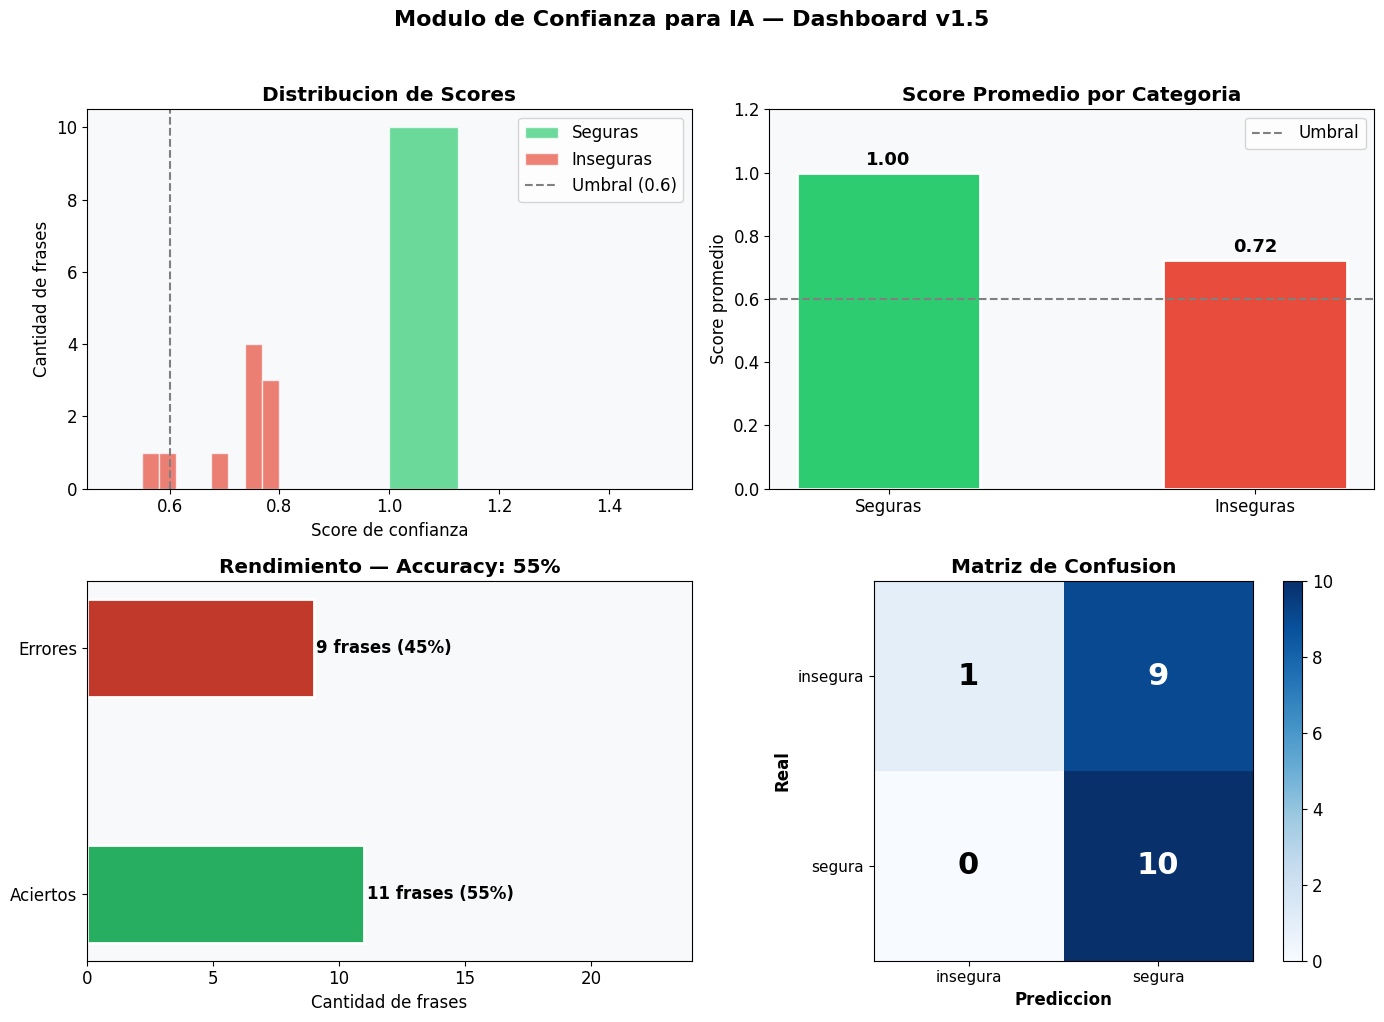

In [ ]:
# ============================================================
# GRAFICAS v1.5
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Modulo de Confianza para IA — Dashboard v1.5",
             fontsize=16, fontweight='bold', y=1.02)

# ── GRAFICA 1: Histograma de scores ──────────────────────────────────────────
ax1 = axes[0, 0]

scores_seguros   = df[df["etiqueta"] == "segura"]["score"]
scores_inseguros = df[df["etiqueta"] == "insegura"]["score"]

ax1.hist(scores_seguros,   bins=8, alpha=0.7, color="#2ecc71", label="Seguras",   edgecolor="white")
ax1.hist(scores_inseguros, bins=8, alpha=0.7, color="#e74c3c", label="Inseguras", edgecolor="white")
ax1.axvline(x=0.6, color='gray', linestyle='--', linewidth=1.5, label="Umbral (0.6)")
ax1.set_title("Distribucion de Scores", fontweight='bold')
ax1.set_xlabel("Score de confianza")
ax1.set_ylabel("Cantidad de frases")
ax1.legend()
ax1.set_facecolor('#f8f9fa')

# ── GRAFICA 2: Score promedio por categoria ───────────────────────────────────
ax2 = axes[0, 1]

categorias  = ["Seguras", "Inseguras"]
promedios   = [scores_seguros.mean(), scores_inseguros.mean()]
colores_bar = ["#2ecc71", "#e74c3c"]

barras = ax2.bar(categorias, promedios, color=colores_bar, width=0.5,
                 edgecolor='white', linewidth=2)

for barra, valor in zip(barras, promedios):
    ax2.text(barra.get_x() + barra.get_width() / 2.,
             barra.get_height() + 0.01,
             f'{valor:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=13)

ax2.set_title("Score Promedio por Categoria", fontweight='bold')
ax2.set_ylabel("Score promedio")
ax2.set_ylim(0, 1.2)
ax2.axhline(y=0.6, color='gray', linestyle='--', linewidth=1.5, label="Umbral")
ax2.legend()
ax2.set_facecolor('#f8f9fa')

# ── GRAFICA 3: Aciertos vs Errores ───────────────────────────────────────────
ax3 = axes[1, 0]

aciertos = df["correcto"].sum()
errores  = len(df) - aciertos

ax3.barh(["Aciertos", "Errores"], [aciertos, errores],
         color=["#27ae60", "#c0392b"], height=0.4,
         edgecolor='white', linewidth=2)

for i, val in enumerate([aciertos, errores]):
    ax3.text(val + 0.1, i,
             f'{val} frases ({val/len(df)*100:.0f}%)',
             va='center', fontweight='bold', fontsize=12)

ax3.set_title(f"Rendimiento — Accuracy: {accuracy*100:.0f}%", fontweight='bold')
ax3.set_xlabel("Cantidad de frases")
ax3.set_xlim(0, len(df) + 4)
ax3.set_facecolor('#f8f9fa')

# ── GRAFICA 4: Matriz de confusion ───────────────────────────────────────────
ax4 = axes[1, 1]

imagen = ax4.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(imagen, ax=ax4)

clases = ["insegura", "segura"]
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
ax4.set_xticklabels(clases, fontsize=11)
ax4.set_yticklabels(clases, fontsize=11)
ax4.set_xlabel("Prediccion", fontsize=12, fontweight='bold')
ax4.set_ylabel("Real", fontsize=12, fontweight='bold')
ax4.set_title("Matriz de Confusion", fontweight='bold')

for i in range(2):
    for j in range(2):
        color_texto = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax4.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 fontsize=22, fontweight='bold', color=color_texto)

plt.tight_layout()
plt.show()

## Seccion 7: IA Explicable — Ver Razonamiento Detallado (NUEVO en v1.5)

Una de las grandes ventajas de la v1.5 es que puedes ver exactamente
**por que** el modelo dio ese score a cada frase.

Esto se llama **IA Explicable (XAI)** y es clave en sistemas criticos
donde necesitas justificar las decisiones del modelo.

In [ ]:
# ============================================================
# IA EXPLICABLE: Reporte detallado por frase
# ============================================================

print("=" * 65)
print("REPORTE EXPLICABLE — MODULO DE CONFIANZA v1.5")
print("=" * 65)

for i, fila in df.iterrows():
    score   = fila["score"]
    nivel   = fila["nivel"]
    razones = fila["razones"]
    correcto = "OK" if fila["correcto"] else "ERROR"

    # Barra visual del score (20 caracteres de ancho)
    barra_len  = int(score * 20)
    barra_visu = "[" + "#" * barra_len + "-" * (20 - barra_len) + "]"

    print(f"\n[{i+1:02d}] {fila['texto'][:60]}")
    print(f"     Score: {score:.2f} {barra_visu} [{nivel}] | {correcto}")
    for razon in razones:
        print(f"     -> {razon}")

print()
print("=" * 65)
print(f"Accuracy final: {accuracy*100:.1f}%")
print("=" * 65)

REPORTE EXPLICABLE — MODULO DE CONFIANZA v1.5

[01] Creo que la capital de Australia es Sydney
     Score: 0.80 [################----] [SEGURA] | ERROR
     -> Detectado: 'creo' (-0.2)

[02] Probablemente el agua hierve a 90 grados
     Score: 0.70 [##############------] [MEDIA] | ERROR
     -> Detectado: 'probablemente' (-0.3)

[03] Quizas Einstein nacio en Francia
     Score: 0.75 [###############-----] [MEDIA] | ERROR
     -> Detectado: 'quizas' (-0.25)

[04] Tal vez el sol es una estrella de tipo M
     Score: 0.75 [###############-----] [MEDIA] | ERROR
     -> Detectado: 'tal vez' (-0.25)

[05] No estoy seguro pero creo que Python fue creado en 1995
     Score: 0.55 [###########---------] [INSEGURA] | OK
     -> Detectado: 'creo' (-0.2)
     -> Detectado: 'no estoy seguro' (-0.35)
     -> Refuerzo: 'seguro' (+0.1)

[06] Me parece que la luna tiene oxigeno
     Score: 0.60 [############--------] [MEDIA] | ERROR
     -> Detectado: 'me parece' (-0.2)
     -> Detectado: 'parece que' (

## Seccion 8: Prueba con tus Propias Frases

Cambia la variable `mi_frase` por cualquier texto que quieras evaluar.

In [ ]:
# ============================================================
# PRUEBA INTERACTIVA
# ============================================================
# Cambia estas frases por las que quieras probar

mis_frases = [
    "El experimento sugiere que el calentamiento global podria revertirse en 10 anos",
    "La Torre Eiffel mide 330 metros de altura incluyendo la antena",
    "Algunos expertos piensan que la vida extraterrestre existe en Europa, la luna de Jupiter",
    "Definitivamente el ADN tiene estructura de doble helice descubierta en 1953",
    "Quizas la inteligencia artificial superara a los humanos pronto",
]

print("EVALUACION DE FRASES PERSONALIZADAS")
print("=" * 65)

for frase in mis_frases:
    score, razones = evaluar_confianza(frase)
    nivel = interpretar_score(score)

    barra_len  = int(score * 20)
    barra_visu = "[" + "#" * barra_len + "-" * (20 - barra_len) + "]"

    print(f"\nFrase:  '{frase}'")
    print(f"Score:  {score:.2f} {barra_visu} [{nivel}]")
    for razon in razones:
        print(f"  -> {razon}")

EVALUACION DE FRASES PERSONALIZADAS

Frase:  'El experimento sugiere que el calentamiento global podria revertirse en 10 anos'
Score:  0.70 [##############------] [MEDIA]
  -> Detectado: 'podria' (-0.2)
  -> Detectado: 'sugiere' (-0.1)

Frase:  'La Torre Eiffel mide 330 metros de altura incluyendo la antena'
Score:  1.00 [####################] [MUY SEGURA]
  -> Sin palabras de incertidumbre ni certeza detectadas

Frase:  'Algunos expertos piensan que la vida extraterrestre existe en Europa, la luna de Jupiter'
Score:  0.75 [###############-----] [MEDIA]
  -> Detectado: 'algunos' (-0.1)
  -> Detectado: 'piensan' (-0.15)

Frase:  'Definitivamente el ADN tiene estructura de doble helice descubierta en 1953'
Score:  1.00 [####################] [MUY SEGURA]
  -> Refuerzo: 'definitivamente' (+0.2)

Frase:  'Quizas la inteligencia artificial superara a los humanos pronto'
Score:  0.75 [###############-----] [MEDIA]
  -> Detectado: 'quizas' (-0.25)


## Seccion 9: Version 2 — Machine Learning con LogisticRegression

### Por que pasar a ML?
La v1.5 es poderosa pero tiene limites:
- Solo detecta las palabras que nosotros definimos manualmente
- No aprende de nuevos datos
- No entiende contexto ni semantica

Con **Logistic Regression + TF-IDF** el modelo aprende automaticamente
que patrones en el texto indican incertidumbre.

> La celda de abajo esta lista — solo necesitas mas datos para activarla.

In [ ]:
# ============================================================
# VERSION 2: MACHINE LEARNING (DESCOMENTA CUANDO TENGAS MAS DATOS)
# ============================================================
# Necesitas al menos 200-500 ejemplos etiquetados para buenos resultados

# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score
#
# # Paso 1: Preparar datos
# X = df['texto']
# y = df['etiqueta']
#
# # Paso 2: Separar en entrenamiento (80%) y prueba (20%)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )
#
# # Paso 3: Crear el pipeline
# # TfidfVectorizer convierte texto en vectores numericos
# # LogisticRegression clasifica basado en esos vectores
# pipeline_v2 = Pipeline([
#     ('tfidf',  TfidfVectorizer(ngram_range=(1, 2))),  # unigramas y bigramas
#     ('modelo', LogisticRegression(max_iter=1000, C=1.0))
# ])
#
# # Paso 4: Entrenar
# pipeline_v2.fit(X_train, y_train)
#
# # Paso 5: Evaluar
# predicciones_v2 = pipeline_v2.predict(X_test)
# acc_v2 = accuracy_score(y_test, predicciones_v2)
# print(f"Accuracy v2 (ML): {acc_v2*100:.1f}%")
#
# # Paso 6: Predecir nuevas frases
# nueva = ["Algunos expertos piensan que la vida extraterrestre existe"]
# print(pipeline_v2.predict(nueva))
# print(pipeline_v2.predict_proba(nueva))  # Score de probabilidad

print("Version 2 preparada.")
print("Descomenta el codigo cuando tengas 200+ ejemplos etiquetados.")
print()
print("Roadmap:")
print("  v1.0 -> Reglas simples")
print("  v1.5 -> Reglas con pesos + IA explicable  (AQUI ESTAMOS)")
print("  v2.0 -> LogisticRegression + TF-IDF")
print("  v3.0 -> BERT / RoBERTa embeddings")
print("  v4.0 -> API REST con FastAPI")

Version 2 preparada.
Descomenta el codigo cuando tengas 200+ ejemplos etiquetados.

Roadmap:
  v1.0 -> Reglas simples
  v1.5 -> Reglas con pesos + IA explicable  (AQUI ESTAMOS)
  v2.0 -> LogisticRegression + TF-IDF
  v3.0 -> BERT / RoBERTa embeddings
  v4.0 -> API REST con FastAPI


## Seccion 10: Resumen Final

In [ ]:
# ============================================================
# RESUMEN FINAL AUTOMATICO
# ============================================================

print("=" * 60)
print("MODULO DE CONFIANZA PARA IA — RESUMEN v1.5")
print("=" * 60)
print()
print(f"Dataset:              {len(df)} frases")
print(f"Palabras incertidumbre: {len(PALABRAS_INCERTIDUMBRE)}")
print(f"Palabras certeza:       {len(PALABRAS_CERTEZA)}")
print()
print(f"Accuracy:             {accuracy*100:.1f}%")
print(f"Score promedio seguras:   {df[df['etiqueta']=='segura']['score'].mean():.2f}")
print(f"Score promedio inseguras: {df[df['etiqueta']=='insegura']['score'].mean():.2f}")
print()
print("Mejoras aplicadas en v1.5:")
print("  [x] Normalizacion de texto con unicodedata")
print("  [x] Score numerico 0.0 - 1.0")
print("  [x] Palabras de certeza")
print("  [x] IA Explicable con razones")
print("  [x] Dashboard con 4 graficas")
print("  [x] Version 2 ML preparada")
print()
print("Estado: Listo para v2.0 con Machine Learning")
print("=" * 60)

MODULO DE CONFIANZA PARA IA — RESUMEN v1.5

Dataset:              20 frases
Palabras incertidumbre: 17
Palabras certeza:       8

Accuracy:             55.0%
Score promedio seguras:   1.00
Score promedio inseguras: 0.72

Mejoras aplicadas en v1.5:
  [x] Normalizacion de texto con unicodedata
  [x] Score numerico 0.0 - 1.0
  [x] Palabras de certeza
  [x] IA Explicable con razones
  [x] Dashboard con 4 graficas
  [x] Version 2 ML preparada

Estado: Listo para v2.0 con Machine Learning


## Seccion 11: Prueba Interactiva con input()

Ejecuta la celda de abajo y escribe cualquier frase directamente en Colab.
El modelo la evaluara al instante y te mostrara el score y las razones.

In [ ]:
# ============================================================
# PRUEBA INTERACTIVA CON INPUT
# ============================================================
# Al ejecutar esta celda, Colab te pedira que escribas una frase
# Escribe tu frase y presiona Enter para ver el resultado

while True:
    print("=" * 60)
    mi_frase = input("Escribe una frase (o 'salir' para terminar): ")

    # Condicion para salir del bucle
    if mi_frase.lower() == "salir":
        print("Cerrando evaluador. Hasta luego!")
        break

    # Validar que no este vacia
    if not mi_frase.strip():
        print("Por favor escribe una frase valida.")
        continue

    # Evaluar la frase
    score, razones = evaluar_confianza(mi_frase)
    nivel = interpretar_score(score)

    # Barra visual del score
    barra_len  = int(score * 20)
    barra_visu = "[" + "#" * barra_len + "-" * (20 - barra_len) + "]"

    # Mostrar resultado
    print()
    print(f"Frase:  '{mi_frase}'")
    print(f"Score:  {score:.2f} {barra_visu} [{nivel}]")
    print("Razones:")
    for razon in razones:
        print(f"  -> {razon}")
    print()

Escribe una frase (o 'salir' para terminar): algunos científicos ven en la complejidad del universo (cosmología, física, biología) evidencias de un creador inteligente, mientras otros, como Stephen Hawking, argumentan que la ciencia no requiere de un dios para explicar el origen del universo. Muchos reconocen que la ciencia no puede demostrar ni refutar la existencia de Dios, ya que opera fuera de lo natural

Frase:  'algunos científicos ven en la complejidad del universo (cosmología, física, biología) evidencias de un creador inteligente, mientras otros, como Stephen Hawking, argumentan que la ciencia no requiere de un dios para explicar el origen del universo. Muchos reconocen que la ciencia no puede demostrar ni refutar la existencia de Dios, ya que opera fuera de lo natural'
Score:  0.90 [##################--] [SEGURA]
Razones:
  -> Detectado: 'algunos' (-0.1)

Escribe una frase (o 'salir' para terminar): La investigación científica demuestra que el deporte y el ejercicio de alta i